In [163]:
import warnings
warnings.filterwarnings('ignore')

In [186]:
import os
import gc
import json
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from lightgbm import LGBMClassifier

from tqdm.notebook import tqdm
from utils import reduce_mem_usage

In [165]:
with open(r'prep_data/unique_dict.txt', 'r', encoding='utf-8') as f:
    dict_key = json.load(f)
columns_for_enc = [dict_key[col] for col in dict_key.keys()]

In [4]:
feature_names = [f'{key}_{value}' for key, values in dict_key.items() for value in values[1:]]

In [5]:
feature_names_id = feature_names + ['id']

In [6]:
feature_names_std = [name + '_std' for name in feature_names]

In [7]:
feature_names_std_id = feature_names_std + ['id']

In [9]:
cat_cols = list(dict_key.keys())

In [10]:
model = joblib.load(r'models/automl_model.pkl')

In [11]:
df_norm = pd.read_csv('stats.csv', index_col=0)

In [12]:
df_norm.columns = [name + '_std' for name in df_norm.columns]

In [13]:
df_norm.head()

,rn_2_std,rn_3_std,rn_4_std,rn_5_std,rn_6_std,rn_7_std,rn_8_std,rn_9_std,rn_10_std,rn_11_std,...,enc_loans_credit_type_1_std,enc_loans_credit_type_2_std,enc_loans_credit_type_3_std,enc_loans_credit_type_4_std,enc_loans_credit_type_5_std,enc_loans_account_cur_1_std,enc_loans_account_cur_2_std,enc_loans_account_cur_3_std,pclose_flag_1_std,fclose_flag_1_std
mean,0.926485,0.850270,0.773577,0.698063,0.625503,0.556179,0.491332,0.431469,0.376768,0.327418,...,0.293399,0.205795,2.578744,4.924995,0.350115,8.700294,0.017701,0.000061,1.301141,1.996808
std,0.260980,0.356807,0.418516,0.459098,0.483993,0.496834,0.499925,0.495281,0.484576,0.469271,...,0.817462,0.576817,2.077044,4.178037,1.597446,6.170750,0.169106,0.008386,1.365645,1.688054


In [14]:
class MemoryReduceTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self.stats_ = None

    def fit(self, X, y):
        self.stats_ = reduce_mem_usage(X)
        return self

    def transform(self, X):
        X = self.stats_
        return X

In [15]:
class AggregationTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, df_norm: pd.DataFrame, agg_func: str='sum'):
        self.agg_func = agg_func
        self.df_norm = df_norm

    def fit(self, X, y):
        return self

    def transform(self, X):
        df_temp = X.groupby('id').agg(self.agg_func)
        for column in df_temp.columns:
            mean = self.df_norm.loc['mean', column]
            std = self.df_norm.loc['std', column]
            df_temp[column] = (df_temp[column] - mean)/std
        return df_temp

In [16]:
class SpyTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = pd.DataFrame(X, columns=self.cols)
        return df

In [17]:
class TrainedAutoMLWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, automl_model, names):
        self.automl_model = automl_model
        self.names = names

    def fit(self, X, y=None):
        return self  

    def predict(self, X):
        df = pd.DataFrame(X, columns=self.names)
        df = df[self.automl_model.reader.used_features]
        return self.automl_model.predict(df)

In [18]:
first_transformer = Pipeline(steps=[
    #('red_mem', MemoryReduceTransformer()),
    ('onehot', OneHotEncoder(categories=columns_for_enc, sparse_output=False, handle_unknown='ignore', drop='first')),
])

In [19]:
second_transformer = Pipeline(steps=[
    ('agg_trans', AggregationTransformer(df_norm=df_norm)),
    #('scaler', StandardScaler()),
])

In [20]:
preprocessor_1 = ColumnTransformer(
    transformers=[('first', first_transformer, cat_cols)],
    remainder='passthrough'      
)

In [21]:
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('second', second_transformer, feature_names_std_id),
    ]
)

In [22]:
clf = Pipeline(steps=[
    ('preprocess_1', preprocessor_1),
    ('spy', SpyTransformer(cols=feature_names_std_id)),
    ('preprocess_2', preprocessor_2),
    ('model', TrainedAutoMLWrapper(model, feature_names_std))
])

In [23]:
path_raw = os.path.join(os.path.abspath(os.curdir), 'raw_data')

In [24]:
files = [filename for filename in os.listdir(path_raw) if filename.startswith('train')]

In [156]:
all_probs = {}
y = pd.read_csv(r'raw_data/target.csv')
y['probs'] = -1
flag_fit = False
STEP = 1000

In [157]:
for file in tqdm(files):
    file_path = os.path.join('raw_data', file)
    X = pd.read_parquet(file_path)
    print('-------------------------------------')
    print(f'Читаем файл {file_path}')
    X = reduce_mem_usage(X)
    uniqs_id = X['id'].unique()
    
    print(f'МАКСИМАЛЬНЫЙ ID ПОЛЬЗОВАТЕЛЯ: {uniqs_id[-1]}')
    
    for idx in tqdm(range(0, len(uniqs_id), STEP)):
        #print()
        #print(f'Пользователи: {uniqs_id[idx]} - {uniqs_id[idx + (STEP - 1)]}')
        
        sample_idx = uniqs_id[idx:idx+STEP]
        mask = X['id'].isin(sample_idx)
        X_sample = X[mask]
        mask = y['id'].isin(sample_idx)
        y_sample = y[mask]
        y_sample = y_sample.drop(columns=['id', 'probs'])
        if not flag_fit:
            clf.fit(X_sample, y_sample)
            flag_fit = True
        y_pred_proba = clf.predict(X_sample)
        proba = y_pred_proba.data[:,0].tolist()
        y['probs'][mask] = proba

  0%|          | 0/12 [00:00<?, ?it/s]

-------------------------------------
Читаем файл raw_data/train_data_0.pq
Используемая память до преобразования 0.897 Gb


  0%|          | 0/61 [00:00<?, ?it/s]

Используемая память после преобразования: 0.118 Gb
Количество используемой памяти уменьшено на 86.9%
МАКСИМАЛЬНЫЙ ID ПОЛЬЗОВАТЕЛЯ: 249999


  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

-------------------------------------
Читаем файл raw_data/train_data_5.pq
Используемая память до преобразования 0.978 Gb


  0%|          | 0/61 [00:00<?, ?it/s]

Используемая память после преобразования: 0.128 Gb
Количество используемой памяти уменьшено на 86.9%
МАКСИМАЛЬНЫЙ ID ПОЛЬЗОВАТЕЛЯ: 1499999


  0%|          | 0/250 [00:00<?, ?it/s]

In [159]:
y['preds'] = (y['probs'] >= 0.5).astype(int)

In [160]:
y.head()

,id,flag,probs,preds
0,0,0,0.346820,0
1,1,0,0.398750,0
2,2,0,0.523021,1
3,3,0,0.239882,0
4,4,0,0.579520,1


In [161]:
auc_test = roc_auc_score(y['flag'], y['probs'])
print(f'AUC на тесте: {auc_test:.4f}')

AUC на тесте: 0.6377


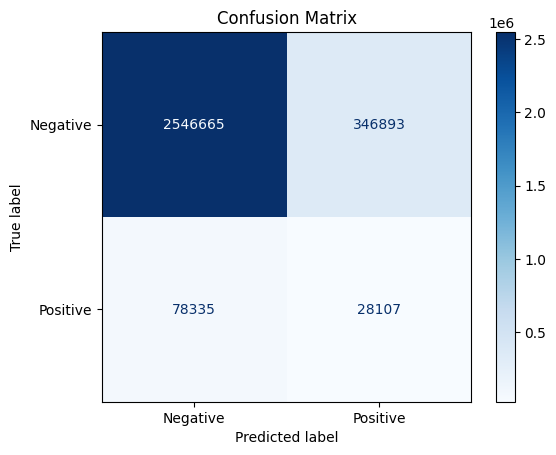

In [162]:
cm = confusion_matrix(y['flag'], y['preds'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()